# Binary Classification problem: comparison of Decision Tree Classifier vs. XGBoost Classifier on BrainCancer Dataset

## Import Libraries

In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

SEED = 445

## Loading our Dataset & EDA
We examine the data and drop the null values 

In [4]:
# Load dataset
df = pd.read_csv("../datasets/BC-BrainCancer.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Shape before dropping missing values:", df.shape)
print("Missing values per column:")
print(df.isna().sum())

df = df.dropna()
print("\nShape after dropping missing values:", df.shape)

print("\nClass balance (status):")
print(df["status"].value_counts())

Shape before dropping missing values: (88, 6)
Missing values per column:
sex          0
diagnosis    1
loc          0
ki           0
gtv          0
status       0
dtype: int64

Shape after dropping missing values: (87, 6)

Class balance (status):
status
0    52
1    35
Name: count, dtype: int64


## Feature Encoding & Splitting the dataset 
The sequential (non-shuffled) 70% / 15% / 15% split is done exactly as provided in the assignment instruction, using
library function `train_test_split(..., shuffle=False)` applied twice.

In [5]:
X = df.drop(columns=["status"])
y = df["status"]

X = pd.get_dummies(X, drop_first=True)
X.reset_index(drop=True, inplace=True)
y = y.reset_index(drop=True)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, shuffle=False)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])
print("\nFeatures used:", list(X.columns))

Train size: 60
Validation size: 13
Test size: 14

Features used: ['ki', 'gtv', 'sex_Male', 'diagnosis_LG glioma', 'diagnosis_Meningioma', 'diagnosis_Other', 'loc_Supratentorial']


## Custom Evaluation Metrics
We manually implement Confusion Matrix, Accuracy, Precision, Recall, F1 with
NumPy. These work for the binary case as well as for 2x2 confusion matrix.

In [6]:
# Confusion Matrix

def custom_confusion_matrix(y_actual, y_predicted):
    y_true = np.array(y_actual, dtype=int)
    y_pred = np.array(y_predicted, dtype=int)

    num_classes = max(np.max(y_true), np.max(y_pred)) + 1

    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        confusion_matrix[actual][predicted] += 1

    return confusion_matrix


def custom_accuracy(y_actual, y_predicted):
    confusion_matrix = custom_confusion_matrix(y_actual, y_predicted)
    correct = np.trace(confusion_matrix)
    total = np.sum(confusion_matrix)

    if total == 0:
        return 0.0
    else:
        return correct / total


def custom_precision(y_actual, y_predicted):
    confusion_matrix = custom_confusion_matrix(y_actual, y_predicted)

    precision_scores = []

    for i in range(len(confusion_matrix)):
        trueP = confusion_matrix[i][i]
        falseP = np.sum(confusion_matrix[:, i]) - trueP

        if trueP + falseP == 0:
            precision_scores.append(0.0)
        else:
            precision_scores.append(trueP / (trueP + falseP))

    return np.mean(precision_scores)


def custom_recall(y_actual, y_predicted):
    confusion_matrix = custom_confusion_matrix(y_actual, y_predicted)

    recall_scores = []

    for i in range(len(confusion_matrix)):
        trueP = confusion_matrix[i][i]
        falseN = np.sum(confusion_matrix[i, :]) - trueP

        if trueP + falseN == 0:
            recall_scores.append(0.0)
        else:
            recall_scores.append(trueP / (trueP + falseN))

    return np.mean(recall_scores)


def custom_f1(y_actual, y_predicted):
    confusion_matrix = custom_confusion_matrix(y_actual, y_predicted)
    f1_scores = []
    for i in range(len(confusion_matrix)):
        trueP = confusion_matrix[i][i]
        falseP = np.sum(confusion_matrix[:, i]) - trueP
        falseN = np.sum(confusion_matrix[i, :]) - trueP
        if trueP + falseP == 0:
            precision = 0.0
        else:
            precision = trueP / (trueP + falseP)

        if trueP + falseN == 0:
            recall = 0.0
        else:
            recall = trueP / (trueP + falseN)

        if precision + recall == 0:
            f1_scores.append(0.0)
        else:
            f1_scores.append((2 * precision * recall) / (precision + recall))
    return np.mean(f1_scores)


def custom_classification_report(y_actual, y_predicted):
    confusion_matrix = custom_confusion_matrix(y_actual, y_predicted)
    return {
        "accuracy": custom_accuracy(y_actual, y_predicted),
        "precision": custom_precision(y_actual, y_predicted),
        "recall": custom_recall(y_actual, y_predicted),
        "f1": custom_f1(y_actual, y_predicted),
        "confusion_matrix": confusion_matrix,
    }

## Decision Tree Classifier 
We have a predefined set of Hyperparameters Every
combination is trained on `X_train`/`y_train` and scored on `X_val`/`y_val`
with `custom_accuracy`; the combination with the highest validation accuracy
is kept as `best`.

In [7]:
# Decision Tree Classifier
DT_Hyperparameters = {
    "max_depth": [3, 5, 7, 10, 12, None],
    "min_samples_split": [2, 5, 10, 20, 30],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "criterion": ["gini", "entropy", "log_loss"],
}

results = []
best = {
    "accuracy": -1,
    "parameters": None,
    "model": None
}

for depth in DT_Hyperparameters["max_depth"]:
    for min_samples_split in DT_Hyperparameters["min_samples_split"]:
        for min_samples_leaf in DT_Hyperparameters["min_samples_leaf"]:
            for criterion in DT_Hyperparameters["criterion"]:
                model = DecisionTreeClassifier(
                    max_depth=depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    criterion=criterion,
                    random_state=SEED
                )
                model.fit(X_train, y_train)
                validation_pred = model.predict(X_val)
                validation_accuracy = custom_accuracy(y_val, validation_pred)
                results.append(
                    (
                        depth,
                        min_samples_split,
                        min_samples_leaf,
                        criterion,
                        validation_accuracy
                    )
                )
                if validation_accuracy > best["accuracy"]:
                    best["accuracy"] = validation_accuracy
                    best["parameters"] = (
                        depth,
                        min_samples_split,
                        min_samples_leaf,
                        criterion
                    )
                    best["model"] = model

dt_results_df = pd.DataFrame(
    results,
    columns=[
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "criterion",
        "val_accuracy"
    ]
).sort_values(
    by="val_accuracy",
    ascending=False
).reset_index(drop=True)

dt_best = best
dt_test_pred = dt_best["model"].predict(X_test)
dt_test_report = custom_classification_report(y_test, dt_test_pred)

print("Best Decision Tree parameters (max_depth, min_samples_split, min_samples_leaf, criterion):")
print(dt_best["parameters"])
print("Decision Tree Validation Accuracy:", dt_best["accuracy"])
print()
print(dt_results_df.head(10))
print()
print("Decision Tree Test Report:")
print(dt_test_report)

Best Decision Tree parameters (max_depth, min_samples_split, min_samples_leaf, criterion):
(3, 2, 5, 'gini')
Decision Tree Validation Accuracy: 0.8461538461538461

   max_depth  min_samples_split  min_samples_leaf criterion  val_accuracy
0        NaN                 20                 5  log_loss      0.846154
1        NaN                 20                 5   entropy      0.846154
2        NaN                 20                 5      gini      0.846154
3        3.0                  5                 5  log_loss      0.846154
4        3.0                  5                 5   entropy      0.846154
5        3.0                  5                 5      gini      0.846154
6        NaN                 10                 5  log_loss      0.846154
7        NaN                 10                 5   entropy      0.846154
8        NaN                 10                 5      gini      0.846154
9        NaN                 10                 2      gini      0.846154

Decision Tree Test Re

making confusion matrix for Decision tree

In [8]:
dt_confusion_df = pd.DataFrame(
    dt_test_report["confusion_matrix"],
    index=[f"Actual {c}" for c in range(dt_test_report["confusion_matrix"].shape[0])],
    columns=[f"Predicted {c}" for c in range(dt_test_report["confusion_matrix"].shape[0])]
)
print("Decision Tree Confusion Matrix (Test Set):")
dt_confusion_df

Decision Tree Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,8,3
Actual 1,1,2


## XGBoost Classifier
we define the hyperparameters and use fixed-seed random-search loop. Every sampled combination
is trained on `X_train`/`y_train` and scored on `X_val`/`y_val` with our very own 
`custom_accuracy`.

In [9]:
#Using XGBoost Classifier
XGB_Hyperparameters = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "gamma": [0, 0.1],
}
random_number_generator = np.random.RandomState(SEED)
keys = list(XGB_Hyperparameters.keys())

all_combinations = []
results = []
best = {
    "accuracy": -1,
    "parameters": None,
    "model": None
}

for i in range(180):
    combination = {
        key: XGB_Hyperparameters[key][random_number_generator.randint(len(XGB_Hyperparameters[key]))]
        for key in keys
    }
    all_combinations.append(tuple(sorted(combination.items())))
unique_combinations = list(dict.fromkeys(all_combinations))[:60]

for combination in unique_combinations:
    params = dict(combination)
    model = XGBClassifier(
        objective="binary:logistic",
        random_state=SEED,
        n_jobs=4,
        verbosity=0,
        eval_metric="logloss",
        **params
    )

    model.fit(X_train, y_train)
    validation_pred = model.predict(X_val)
    validation_accuracy = custom_accuracy(y_val, validation_pred)

    results.append(
        (
            params["max_depth"],
            params["learning_rate"],
            params["n_estimators"],
            params["subsample"],
            params["colsample_bytree"],
            params["min_child_weight"],
            params["gamma"],
            validation_accuracy
        )
    )

    if validation_accuracy > best["accuracy"]:
        best["accuracy"] = validation_accuracy
        best["parameters"] = params
        best["model"] = model

xgb_results_df = pd.DataFrame(
    results,
    columns=[
        "max_depth",
        "learning_rate",
        "n_estimators",
        "subsample",
        "colsample_bytree",
        "min_child_weight",
        "gamma",
        "val_accuracy"
    ]
).sort_values(
    by="val_accuracy",
    ascending=False
).reset_index(drop=True)

xgb_best = best
xgb_test_pred = xgb_best["model"].predict(X_test)
xgb_test_report = custom_classification_report(y_test, xgb_test_pred)

print("Best XGBoost parameters:")
print(xgb_best["parameters"])
print("XGBoost Validation Accuracy:", xgb_best["accuracy"])
print()
print(xgb_results_df.head(10))
print()
print("XGBoost Test Report:")
print(xgb_test_report)

Best XGBoost parameters:
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
XGBoost Validation Accuracy: 0.8461538461538461

   max_depth  learning_rate  n_estimators  subsample  colsample_bytree  \
0          5           0.01           100        0.8               0.8   
1          5           0.01           300        0.8               0.8   
2          7           0.05           300        0.8               0.8   
3          3           0.05           300        0.8               0.8   
4          5           0.01           300        1.0               0.8   
5          3           0.01           300        0.8               1.0   
6          3           0.10           300        0.8               0.8   
7          7           0.05           300        0.8               0.8   
8          7           0.01           300        0.8               1.0   
9          5           0.10           100    

Confusion Matrix for XGboost

In [10]:
xgb_confusion_df = pd.DataFrame(
    xgb_test_report["confusion_matrix"],
    index=[f"Actual {c}" for c in range(xgb_test_report["confusion_matrix"].shape[0])],
    columns=[f"Predicted {c}" for c in range(xgb_test_report["confusion_matrix"].shape[0])]
)
print("XGBoost Confusion Matrix (Test Set):")
xgb_confusion_df

XGBoost Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,9,2
Actual 1,0,3


## Results Comparison
Final comparison of Decision Tree vs. XGBoost on the test set, using the same
manually implemented metrics for both models.

In [11]:
comparison_df = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Validation Accuracy": dt_best["accuracy"],
        "Test Accuracy": dt_test_report["accuracy"],
        "Test Precision": dt_test_report["precision"],
        "Test Recall": dt_test_report["recall"],
        "Test F1": dt_test_report["f1"],
    },
    {
        "Model": "XGBoost",
        "Validation Accuracy": xgb_best["accuracy"],
        "Test Accuracy": xgb_test_report["accuracy"],
        "Test Precision": xgb_test_report["precision"],
        "Test Recall": xgb_test_report["recall"],
        "Test F1": xgb_test_report["f1"],
    },
])

print("Decision Tree Confusion Matrix:")
print(dt_confusion_df)
print()
print("XGBoost Confusion Matrix:")
print(xgb_confusion_df)
print()
print("Final Comparison:")
comparison_df

Decision Tree Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0            8            3
Actual 1            1            2

XGBoost Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0            9            2
Actual 1            0            3

Final Comparison:


,Model,Validation Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Decision Tree,0.846154,0.714286,0.644444,0.696970,0.650
1,XGBoost,0.846154,0.857143,0.800000,0.909091,0.825


## Precision Recall Curve 

Decision Tree — Average Precision: 0.4444444444444444
XGBoost — Average Precision: 0.8666666666666667


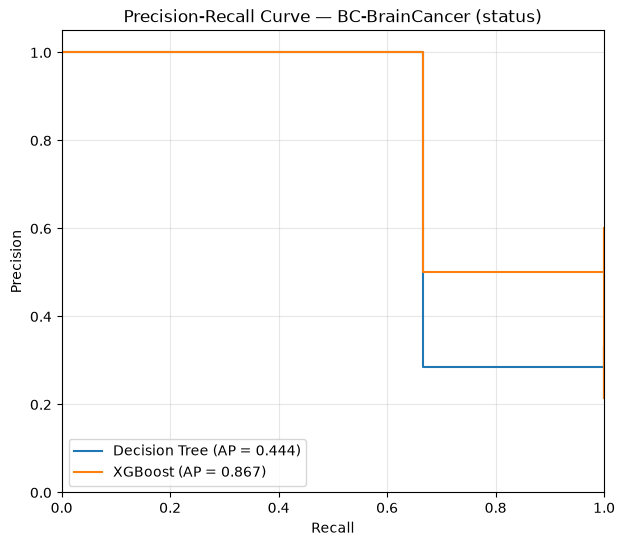

In [12]:
import matplotlib.pyplot as plt

def custom_precision_recall_curve(y_true, y_scores):
    y_true = np.asarray(y_true).astype(int)
    y_scores = np.asarray(y_scores).astype(float)

    
    thresholds = np.sort(np.unique(y_scores))[::-1]
    thresholds = np.concatenate([[1.0], thresholds]) if thresholds[0] < 1.0 else thresholds

    precisions = []
    recalls = []
    for t in thresholds:
        y_pred_t = (y_scores >= t).astype(int)
        tp = int(np.sum((y_pred_t == 1) & (y_true == 1)))
        fp = int(np.sum((y_pred_t == 1) & (y_true == 0)))
        fn = int(np.sum((y_pred_t == 0) & (y_true == 1)))

        precision = 1.0 if (tp + fp) == 0 else tp / (tp + fp)
        recall = 0.0 if (tp + fn) == 0 else tp / (tp + fn)

        precisions.append(precision)
        recalls.append(recall)

   
    precisions.append(np.sum(y_true == 1) / len(y_true))
    recalls.append(1.0)

    return np.array(precisions), np.array(recalls), thresholds


def custom_average_precision(precisions, recalls):
    ap = 0.0
    for n in range(1, len(precisions)):
        ap += (recalls[n] - recalls[n - 1]) * precisions[n]
    return ap


# Decision Tree: predicted probability of status = 1
dt_test_scores = dt_best["model"].predict_proba(X_test)[:, 1]
dt_precisions, dt_recalls, _ = custom_precision_recall_curve(y_test, dt_test_scores)
dt_avg_precision = custom_average_precision(dt_precisions, dt_recalls)

# XGBoost: predicted probability of status = 1
xgb_test_scores = xgb_best["model"].predict_proba(X_test)[:, 1]
xgb_precisions, xgb_recalls, _ = custom_precision_recall_curve(y_test, xgb_test_scores)
xgb_avg_precision = custom_average_precision(xgb_precisions, xgb_recalls)

print("Decision Tree — Average Precision:", dt_avg_precision)
print("XGBoost — Average Precision:", xgb_avg_precision)

plt.figure(figsize=(7, 6))
plt.step(dt_recalls, dt_precisions, where="post", label=f"Decision Tree (AP = {dt_avg_precision:.3f})")
plt.step(xgb_recalls, xgb_precisions, where="post", label=f"XGBoost (AP = {xgb_avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — BC-BrainCancer (status)")
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()


The Precision-Recall curve clearly shows that XGBoost outperformed the Decision Tree by a wide margin. While the Decision Tree achieved an Average Precision (AP) of only 0.444, XGBoost reached an impressive 0.866, more than doubling the Decision Tree's performance. The Decision Tree's precision drops rapidly as recall increases, indicating that it produces many false positives when attempting to identify more positive instances. In contrast, XGBoost maintains consistently high precision across almost the entire recall range, demonstrating a much stronger ability to correctly identify positive cases without sacrificing prediction quality. Overall, the results indicate that XGBoost is significantly more reliable and effective than the Decision Tree for this dataset, making it the clearly superior model.